In [1]:
import json
import os 
import glob
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader

In [2]:
# copy from notebook 3
class LazyDatasetList(Dataset):
    def __init__(self, data_files, transform=None, time_interval=timedelta(minutes=10)):
        """
        Custom PyTorch Dataset for loading time-sequenced data.

        Args:
            data_files (list): List of file paths (each file contains a tensor).
            transform (callable, optional): Optional transform to apply to each tensor.
            time_interval (timedelta): Expected time gap between consecutive files.
        """
        
        # Store inputs
        self.data_files = data_files
        self.transform = transform
        self.time_interval = time_interval

        # Format expected in filenames (e.g. "202101010040")
        self.time_format = "%Y%m%d%H%M"

        # Dictionary mapping datetime -> file path
        self.time_to_file = {}

        # Extract timestamps from filenames and build mapping
        for f in self.data_files:
            # Get filename without extension
            ts = os.path.splitext(os.path.basename(f))[0]

            try:
                # Convert filename string to datetime object
                dt = datetime.strptime(ts, self.time_format)

                # Store mapping
                self.time_to_file[dt] = f

            except ValueError:
                # Skip files that don't match expected timestamp format
                continue

        # Sort all valid timestamps
        sorted_times = sorted(self.time_to_file.keys())

        # Build sequences of 4 time steps: [t-3, t-2, t-1, t]
        self.time_list = []

        for t in sorted_times:
            # Define previous time steps
            next_t = t - self.time_interval       # t-1
            next_t_2 = next_t - self.time_interval # t-2
            next_t_3 = next_t_2 - self.time_interval # t-3

            # Only keep sequences where ALL previous timesteps exist
            if (
                next_t in self.time_to_file and
                next_t_2 in self.time_to_file and
                next_t_3 in self.time_to_file
            ):
                # Store tuple of file paths for this sequence
                self.time_list.append((
                    self.time_to_file[t],        # current time (t)
                    self.time_to_file[next_t],   # t-1
                    self.time_to_file[next_t_2], # t-2
                    self.time_to_file[next_t_3]  # t-3
                ))

    def __len__(self):
        """
        Total number of valid 4-step sequences in the dataset.
        """
        return len(self.time_list)

    def __getitem__(self, idx):
        """
        Load a single sample (sequence of 4 timesteps).

        Returns:
            dict:
                'data': Tensor of shape (4, ...)
                'source': String listing filenames used
        """

        # Get file paths for this sequence
        f_t, f_t_1, f_t_2, f_t_3 = self.time_list[idx]

        # Create a string identifying the source files
        full_str = f'{os.path.basename(f_t_3)},{os.path.basename(f_t_2)},{os.path.basename(f_t_1)},{os.path.basename(f_t)}'

        # Load data for each timestep
        data_list = []

        # IMPORTANT: note the order is [t-3, t-2, t-1, t]
        for t_step in [f_t_3, f_t_2, f_t_1, f_t]:

            # Load tensor from file
            data = torch.load(t_step)

            # Add a channel dimension (e.g. from HxW → 1xHxW)
            data = data.unsqueeze(0)

            # Apply optional transform (e.g. normalization)
            if self.transform:
                data = self.transform(data)

            data_list.append(data)

        # Stack tensors along time dimension → shape (4, C, H, W) typically
        data = torch.cat(data_list, dim=0)

        return {
            'data': data,
            'source': full_str
        }

In [3]:
from dataclasses import dataclass
import torch
from diffusers import UNet2DModel
from diffusers import DDPMScheduler
from safetensors.torch import load_file

In [24]:
@dataclass
class EvaluationConfig:
    in_channels = 4
    out_channels = 1
    image_size = 64
    eval_batch_size = 2
    output_dir = "/scratch/nf33/cd3022/pyearth/model"
    seed = 0


@torch.no_grad()  # disables gradient tracking → faster + less memory
def evaluate_conditioned(config, model, noise_scheduler, batch):

    # -----------------------------
    # Device setup
    # -----------------------------
    device = torch.device("cuda")


    # -----------------------------
    # Extract conditioning frames
    # -----------------------------
    # shape: (B, 3, H, W)
    condition_images = batch["data"][:, 0:3, :, :].detach().to(device)

    batch_size = condition_images.shape[0]


    # -----------------------------
    # Initialise with pure noise
    # -----------------------------
    # This is the key difference from training:
    # we START from noise and denoise step-by-step

    image_shape = (
        batch_size,
        config.out_channels,   # 1 channel (target frame)
        config.image_size,
        config.image_size
    )

    image = torch.randn(image_shape, device=device)


    # -----------------------------
    # Reverse diffusion loop
    # -----------------------------
    for t in noise_scheduler.timesteps:

        # -----------------------------------------
        # Prepare model input
        # -----------------------------------------
        # Combine:
        # - current noisy image estimate
        # - conditioning frames

        x_t = torch.cat([image, condition_images], dim=1).to(torch.float32)


        # -----------------------------------------
        # Prepare timestep tensor
        # -----------------------------------------
        t_batch = t.expand(batch_size).to(torch.float32).to(device)


        # -----------------------------------------
        # Predict noise
        # -----------------------------------------
        noise_pred = model(
            x_t,
            t_batch,
            return_dict=False
        )[0]


        # -----------------------------------------
        # Denoising step
        # -----------------------------------------
        # Move one step toward a cleaner image

        image = noise_scheduler.step(
            noise_pred,
            t.cpu(),   # scheduler expects CPU timestep
            image
        ).prev_sample


    # -----------------------------
    # Return final generated images
    # -----------------------------
    return list(image.cpu())

In [32]:
# -----------------------------
# Create evaluation config
# -----------------------------
config = EvaluationConfig()


# -----------------------------
# Device (GPU)
# -----------------------------
device = torch.device("cuda")


# -----------------------------
# Data directory
# -----------------------------
input_dir = '/scratch/nf33/cd3022/pyearth'


# -----------------------------
# Load normalization stats
# -----------------------------
# NOTE: using float32 here (not bf16 like training)
# → more stable for inference

with open('/scratch/nf33/cd3022/pyearth/min_max.json', 'r') as f:
    stats = json.load(f)

    min_vals = torch.tensor(stats['min'], dtype=torch.float32)
    max_vals = torch.tensor(stats['max'], dtype=torch.float32)


# -----------------------------
# Build dataset
# -----------------------------
data_files = sorted(glob.glob(os.path.join(input_dir, '*.pt')))

dataset = LazyDatasetList(
    data_files,
    transform=MinMaxToMinusOneOne(min_vals, max_vals)
)


# -----------------------------
# Create DataLoader
# -----------------------------
eval_dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=config.eval_batch_size,
    shuffle=False   # IMPORTANT: keep order for evaluation
)

# -----------------------------
# Recreate the UNet architecture
# -----------------------------
model = UNet2DModel(
    sample_size=config.image_size,
    in_channels=config.in_channels,   # 4 (noisy target + 3 conditions)
    out_channels=config.out_channels, # 1 (predict noise)
    layers_per_block=2,
    block_out_channels=(32, 64, 128, 256),
    down_block_types=(
        "DownBlock2D",  
        "DownBlock2D",
        "AttnDownBlock2D",
        "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D", 
        "AttnUpBlock2D", 
        "UpBlock2D",
        "UpBlock2D",
    ),
).to(device)

state_dict = load_file(
    os.path.join(
        config.output_dir,
        'checkpoint',
        'epoch_2509',
        'unet',
        'diffusion_pytorch_model.safetensors'
    )
)
model.load_state_dict(state_dict)
model.eval()

noise_scheduler = DDPMScheduler(num_train_timesteps=1000)
data=next(iter(eval_dataloader))
noise_scheduler = DDPMScheduler(num_train_timesteps=1000)

/jobfs/163255815.gadi-pbs/ipykernel_3990920/1322016933.py:53: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.min_vals = torch.tensor(min_vals).view(-1, 1, 1)
/jobfs/163255815.gadi-pbs/ipykernel_3990920/1322016933.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.max_vals = torch.tensor(max_vals).view(-1, 1, 1)


In [25]:
# -----------------------------
# Choose run number and output directory
# -----------------------------
run_no = 2

# Directory to save generated samples
save_dir = os.path.join(config.output_dir, "samples", f"run{run_no}")

# Create directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)


# -----------------------------
# Set model to evaluation mode
# -----------------------------
model.eval()


# -----------------------------
# Loop over evaluation data
# -----------------------------
for batch_idx, data in enumerate(eval_dataloader):

    # -----------------------------------------
    # Generate predictions using diffusion
    # -----------------------------------------
    # This runs the reverse diffusion process
    # starting from noise → produces predicted image

    images = evaluate_conditioned(
        config,
        model,
        noise_scheduler,
        data
    )


    # -----------------------------------------
    # Extract filenames for saving
    # -----------------------------------------
    # data["source"] looks like:
    # "t-3.pt,t-2.pt,t-1.pt,t.pt"
    #
    # We take the LAST file (true target time)

    fnames = [s.split(",")[-1] for s in data["source"]]


    # -----------------------------
    # Save generated images
    # -----------------------------
    for i, img in enumerate(images):

        # Construct output path
        out_path = os.path.join(
            save_dir,
            f"generated_image_{fnames[i]}"
        )

        # Save tensor to disk
        torch.save(img, out_path)

Text(0, 0.5, 'Observation')

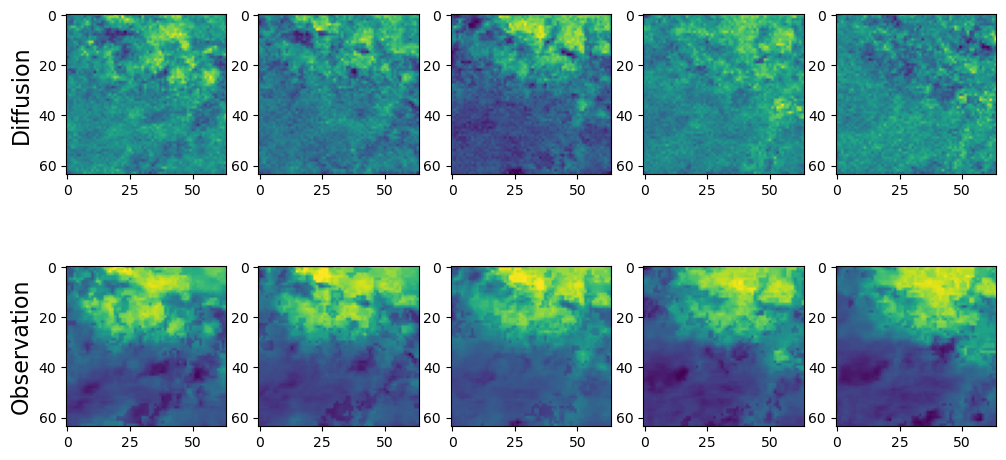

In [78]:
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

#note: all samples are normed. Need to denorm before calculating RMSE.
fig, ax = plt.subplots(nrows=2, ncols=5, figsize=(12, 6))

sample_dir = '/scratch/nf33/cd3022/pyearth/model/samples/run2/'
truth_dir = '/scratch/nf33/cd3022/pyearth/'

start_dt = datetime.strptime('202101010030', '%Y%m%d%H%M')

for i in range(5):
    time_dt = start_dt + timedelta(minutes=10*i)
    time = time_dt.strftime('%Y%m%d%H%M')

    sample=torch.load(f'{sample_dir}generated_image_{time}.pt')
    ax[0, i].imshow(sample[0, :, :])
    
    truth = torch.load(f'{truth_dir}{time}.pt')
    ax[1, i].imshow(truth)

ax[0,0].set_ylabel('Diffusion', fontsize=16)
ax[1,0].set_ylabel('Observation', fontsize=16)